# Tech Challenge FIAP — Fase 1
## Notebook 03 — Avaliacao Aprofundada e Explicabilidade

**Dataset:** Maternal Health Risk Data Set (UCI)  
**Autor:** Igor Natanael

---

### Objetivo deste notebook
1. Retreinar os modelos com os melhores hiperparametros encontrados no Notebook 02.
2. Plotar curvas ROC por classe (One-vs-Rest) para os 3 modelos.
3. Analisar explicabilidade via SHAP: summary plot (global) e waterfall (individual).
4. Discutir criticamente: limitacoes, vieses e uso clinico responsavel do modelo.

## 1. Setup e imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.preprocessing import build_preprocessed_splits
from src.models.train import build_pipelines, run_grid_search, PARAM_GRIDS
from src.evaluation.metrics import evaluate_model, build_comparison_table
from src.evaluation.explainability import (
    plot_roc_curves,
    compute_shap_values,
    plot_shap_summary,
    plot_shap_bar,
    plot_shap_waterfall_single,
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Pre-processamento e retreino dos modelos

Este notebook e auto-contido: refaz o pre-processamento e o GridSearch do zero.
Com ~452 amostras, o tempo total e de poucos minutos.

In [2]:
X_train, X_test, y_train, y_test, scaler = build_preprocessed_splits(
    add_pulse_pressure=True,
    add_age_features=True,
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

PIPELINE DE PRE-PROCESSAMENTO
[load] Dataset carregado: 1014 linhas x 7 colunas
[outliers] Removidas 2 linha(s) com HeartRate < 30 bpm.
[dedup] Removidas 561 duplicatas. Linhas restantes: 451
[features] BodyTemp convertida de Fahrenheit para Celsius.
[features] pulse_pressure criado.
[features] age_advanced e age_group criados.
[split] Treino: 360 linhas | Teste: 91 linhas (20% teste)
[scaler] StandardScaler aplicado (fit no treino, transform em ambos).
-------------------------------------------------------
Features finais (9): ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'pulse_pressure', 'age_advanced', 'age_group']
Distribuicao do alvo — treino:
  low risk (0): 186 (51.7%)
  mid risk (1): 85 (23.6%)
  high risk (2): 89 (24.7%)
Distribuicao do alvo — teste:
  low risk (0): 47 (51.6%)
  mid risk (1): 21 (23.1%)
  high risk (2): 23 (25.3%)
Treino: (360, 9) | Teste: (91, 9)


In [3]:
# Retreino com GridSearch (melhores hiperparametros)
pipelines = build_pipelines()
grid_searches = run_grid_search(pipelines, X_train, y_train)

# Dicionario de melhores pipelines (ja re-treinados no X_train completo)
melhores = {nome: gs.best_estimator_ for nome, gs in grid_searches.items()}
print('\nModelos prontos:', list(melhores.keys()))

[GridSearch] logistic_regression: 5 combinacoes x 5 folds...
  Melhores params : {'model__C': 0.01}
  Melhor F1-macro : 0.5586
[GridSearch] random_forest: 27 combinacoes x 5 folds...
  Melhores params : {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
  Melhor F1-macro : 0.6459
[GridSearch] svm: 16 combinacoes x 5 folds...
  Melhores params : {'model__C': 100.0, 'model__gamma': 0.01}
  Melhor F1-macro : 0.6362

Modelos prontos: ['logistic_regression', 'random_forest', 'svm']


## 3. Curvas ROC por classe (One-vs-Rest)

A curva ROC mede a capacidade do modelo de separar cada classe das demais ao
longo de todos os possiveis limiares de decisao. AUC = 1.0 e perfeito; AUC = 0.5
e equivalente a um classificador aleatorio.

Estrategia **One-vs-Rest (OvR)**: para cada classe k, trata o problema como binario
(classe k vs. todas as outras). Adequado para multiclasse com desbalanceamento moderado.

Foco clinico: a curva da classe `high risk` e a mais critica — queremos AUC alta
e recall alto mesmo ao custo de mais falsos positivos.

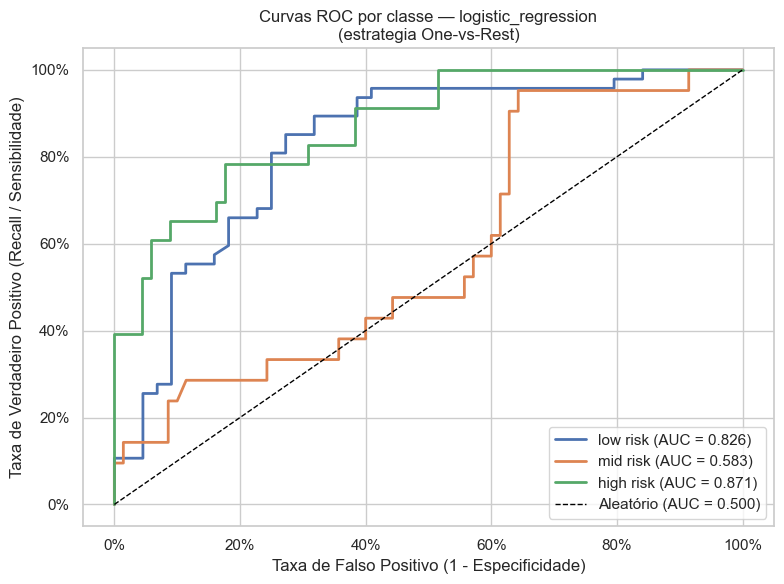

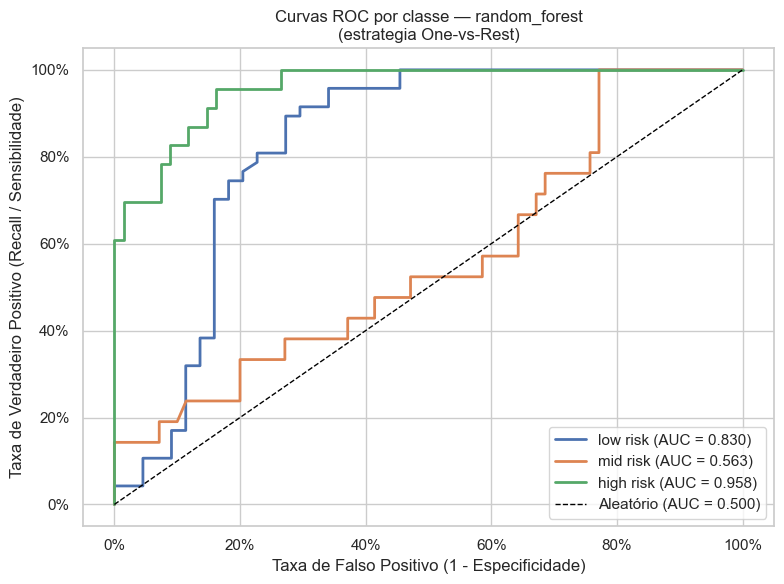

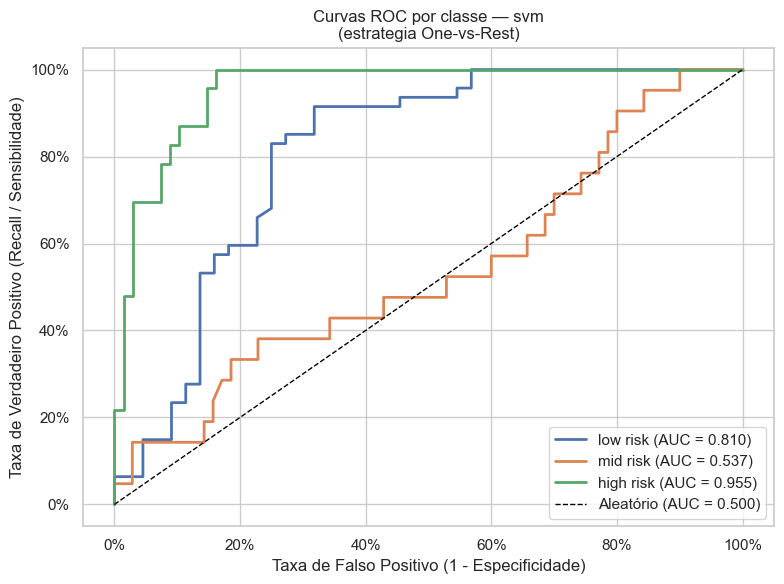


AUC por classe e modelo:


,low risk,mid risk,high risk,macro
logistic_regression,0.8257,0.5827,0.8715,0.7600
random_forest,0.8300,0.5629,0.9584,0.7838
svm,0.8097,0.5371,0.9552,0.7673


In [4]:
auc_series = {}

for nome, pipeline in melhores.items():
    s = plot_roc_curves(
        pipeline=pipeline,
        X_test=X_test,
        y_test=y_test,
        nome_modelo=nome,
        save_path=str(FIGURES_DIR / f'10_roc_{nome}.png'),
    )
    auc_series[nome] = s

df_auc = pd.DataFrame(auc_series).T
print('\nAUC por classe e modelo:')
df_auc

## 4. Analise SHAP

SHAP (SHapley Additive exPlanations) decompoe cada predicao individual em
contribuicoes aditivas de cada feature, baseado na teoria dos jogos cooperativos.

**Por que SHAP?**  
- Consistente: se um modelo usa mais uma feature, seu SHAP sobe — garantido.
- Local e global: explica predicoes individuais E importancia global.
- Agnóstico de modelo: funciona com qualquer tipo de estimador.

Faremos a analise no **Random Forest** (melhor candidato a modelo principal)
e repetiremos para a Regressao Logistica como comparacao interpretativa.

### 4.1 SHAP — Random Forest

In [5]:
# Calcula valores SHAP para o Random Forest no conjunto de teste
explainer_rf, shap_values_rf = compute_shap_values(
    pipeline=melhores['random_forest'],
    X_background=X_train,
    X_explain=X_test,
    tipo_modelo='random_forest',
)
print('SHAP values calculados. Shape:', np.array(shap_values_rf).shape)

SHAP values calculados. Shape: (91, 9, 3)


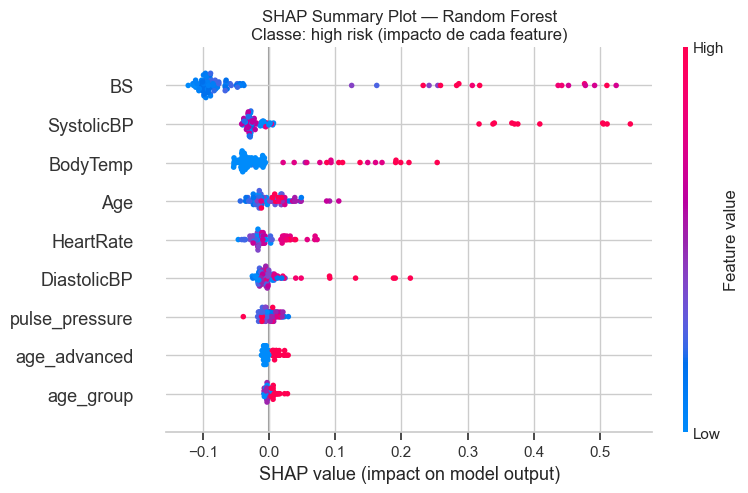

In [6]:
# Summary plot — classe high risk (indice 2)
# Mostra o impacto de cada feature em TODAS as amostras do teste
# Cor vermelha = valor alto da feature; azul = valor baixo
plot_shap_summary(
    shap_values=shap_values_rf,
    X_explain=X_test,
    tipo_modelo='Random Forest',
    classe_idx=2,  # high risk
    save_path=str(FIGURES_DIR / '11_shap_summary_rf_high.png'),
)

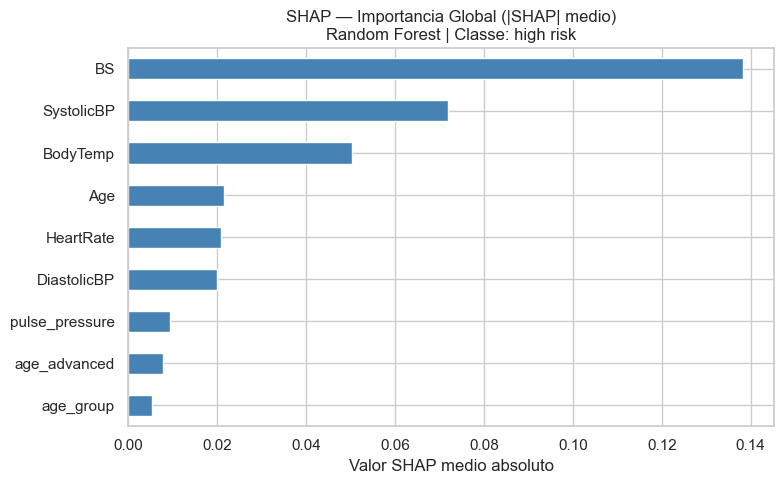

In [7]:
# Bar plot — importancia global por feature (high risk)
plot_shap_bar(
    shap_values=shap_values_rf,
    X_explain=X_test,
    tipo_modelo='Random Forest',
    classe_idx=2,
    save_path=str(FIGURES_DIR / '12_shap_bar_rf_high.png'),
)

### 4.2 Waterfall — predicao individual (high risk)

O waterfall mostra como o modelo chegou a UMA predicao especifica.
Partindo do valor base (media das predicoes no conjunto de treino),
cada feature empurra a predicao para cima (vermelho) ou para baixo (azul).

Esta e a forma mais intuitiva de explicar uma decisao do modelo para um medico:
*"Para esta paciente, a glicemia elevada e a idade de 38 anos empurraram
fortemente para alto risco"*.

Selecionamos uma amostra do teste classificada como `high risk`.

In [8]:
# Encontra uma amostra real de high risk (y_test == 2) no conjunto de teste
indices_high_risk = y_test[y_test == 2].index
# Converte para posicao inteira em X_test (resetado pelo preprocessing)
pos_high_risk = X_test.index.get_indexer(indices_high_risk)
amostra_idx = pos_high_risk[0]  # primeira amostra high risk disponivel

print(f'Amostra selecionada (indice {amostra_idx}):')
print(X_test.iloc[amostra_idx].round(3))
print(f'Classe real: high risk ({y_test.iloc[amostra_idx]})')
print(f'Classe predita: {melhores["random_forest"].predict(X_test.iloc[[amostra_idx]])[0]}')

Amostra selecionada (indice 3):
Age              -0.016
SystolicBP       -1.154
DiastolicBP      -0.393
BS                0.900
BodyTemp          0.954
HeartRate         0.750
pulse_pressure   -1.387
age_advanced     -0.650
age_group        -0.037
Name: 415, dtype: float64
Classe real: high risk (2)
Classe predita: 2


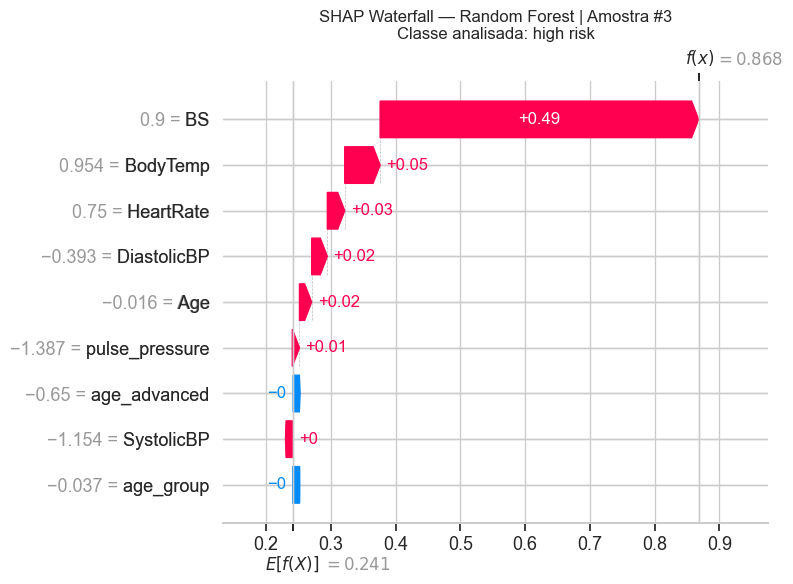

In [9]:
plot_shap_waterfall_single(
    explainer=explainer_rf,
    shap_values=shap_values_rf,
    X_explain=X_test,
    amostra_idx=amostra_idx,
    tipo_modelo='Random Forest',
    classe_idx=2,  # high risk
    save_path=str(FIGURES_DIR / '13_shap_waterfall_rf.png'),
)

### 4.3 SHAP — Regressao Logistica (comparacao)

O LinearExplainer para a Regressao Logistica produz valores SHAP exatos e rapidos.
A comparacao com o Random Forest revela se os dois modelos 'aprenderam' o mesmo
padrao ou se ha divergencias na atribuicao de importancia.

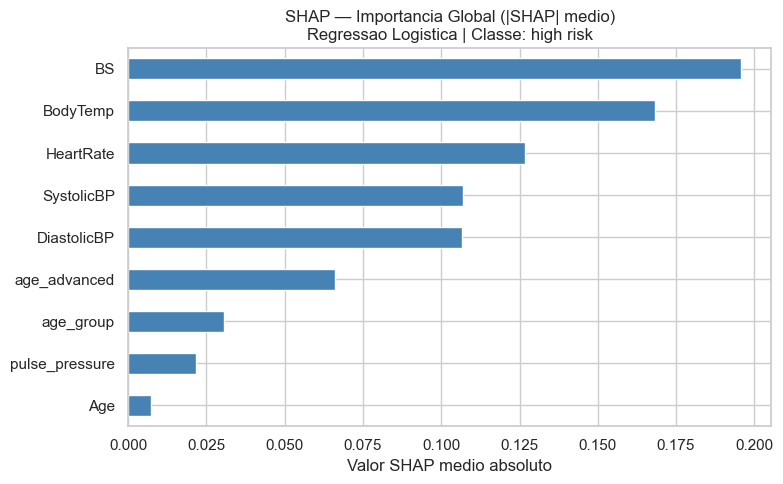

In [10]:
explainer_lr, shap_values_lr = compute_shap_values(
    pipeline=melhores['logistic_regression'],
    X_background=X_train,
    X_explain=X_test,
    tipo_modelo='logistic_regression',
)

plot_shap_bar(
    shap_values=shap_values_lr,
    X_explain=X_test,
    tipo_modelo='Regressao Logistica',
    classe_idx=2,
    save_path=str(FIGURES_DIR / '14_shap_bar_lr_high.png'),
)

## 5. Discussao critica

### 5.1 Por que F1-macro e recall de high risk sao as metricas certas

Em problemas de saude com classes desbalanceadas, a **acuracia simples e enganosa**.
Um modelo que ignorasse completamente a classe `high risk` (27% dos casos) ainda
acertaria ~73% das predicoes — numero alto, mas clinicamente inutil.

O **F1-macro** equilibra precisao e recall de forma igual entre as 3 classes,
penalizando modelos que ignoram classes minoritarias.

O **recall de `high risk`** e a metrica de seguranca clinica: mede quantas
pacientes de alto risco o modelo conseguiu identificar corretamente.
Um falso negativo aqui significa uma paciente de alto risco gestacional
enviada para casa sem acompanhamento adequado — o pior erro possivel
neste contexto. Prefere-se sobrediagnosticar (mais falsos positivos)
a subdiagnosticar (falsos negativos em alto risco).

### 5.2 Limitacoes do modelo e do dataset

**Tamanho da base:** apos remocao de duplicatas, restaram ~452 registros unicos.
Modelos treinados em bases pequenas tem variancia alta — os resultados podem mudar
significativamente com um conjunto de teste diferente. Os valores de CV (k=5) sao
estimativas mais confiaveis que o resultado unico no teste.

**Origem dos dados:** o dataset e proveniente de Bangladesh e foi coletado em
contexto especifico de saude rural. Os padroes aprendidos podem nao generalizar
para populacoes com perfis demograficos, nutricionais e de acesso a saude diferentes.

**Features limitadas:** o modelo usa apenas 6 variaveis clinicas basicas. Fatores
relevantes como historico obstetrico, paridade, IMC, hemoglobina e acesso a
pre-natal nao estao presentes. Isso limita o poder preditivo, especialmente
para a classe `mid risk`, que e frequentemente confundida com `low risk`.

**Duplicatas:** 55% do dataset original eram duplicatas exatas. Esse padrao
sugere que as variaveis sao discretizadas (BP em multiplos de 5/10 mmHg,
idade em anos inteiros), o que limita a granularidade da informacao.

**Rotulagem do alvo:** o `RiskLevel` foi atribuido por profissionais de saude
no contexto original. Nao ha informacao publica sobre o protocolo exato de
rotulagem, o que introduce incerteza sobre a qualidade do ground truth.

### 5.3 Como o modelo se encaixa no fluxo clinico

Este modelo e um **sistema de suporte a decisao** — nao um substituto ao
julgamento clinico. O medico ou enfermeiro tem sempre a palavra final.

Fluxo de uso proposto:
1. Paciente e atendida no pre-natal e tem seus dados basicos coletados
   (pressao, glicemia, temperatura, frequencia cardiaca, idade).
2. O sistema processa os dados e exibe uma **alertas de risco classificado**
   (baixo / medio / alto) com as features que mais contribuiram (via SHAP).
3. O profissional usa o alerta como informacao adicional — nao como diagnostico.
4. Casos classificados como `high risk` sao priorizados para revisao medica
   ou encaminhamento especializado.

O valor clinico nao e substituir o medico, mas **reduzir o tempo de triagem**
em contextos de alta demanda e recursos limitados — como postos de saude rurais,
onde o dataset original foi coletado.

### 5.4 Proximos passos para producao

- Validacao externa em dataset independente (diferente populacao/hospital).
- Analise de fairness: o modelo performa igualmente para diferentes faixas etarias?
- Threshold customizado para `high risk`: ao inves do limiar padrao de 0.5,
  calibrar o limiar para maximizar recall de `high risk` com restricao de
  falsos positivos aceitavel pelo protocolo clinico.
- Monitoramento de drift: o desempenho deve ser reavaliado periodicamente
  conforme novos dados sao coletados.